# Pipeline figure for the GitHub README

Generates `docs/fig2_datapipeline.png`, the schematic shown in `README.md`.
This is the **with-methods** variant of the canonical ESSD Figure 2 (the
paper version omits method names; this one keeps them so the README
documents the public API surface visually).

The thumbnails come from a real per-area composite when one is available
(default: `CW2019_2330` over the OAK mount); without that the figure
still renders, just with glyphs in place of the thumbnails. Output goes
to `../docs/fig2_datapipeline.png`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 9,
    'font.family': 'sans-serif',
})

# Output sits next to LABELING_FOR_COLLABORATORS.md so the README's
# ![pipeline](docs/fig2_datapipeline.png) link resolves on GitHub.
OUT_DIR = Path('../docs').resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('OUT_DIR =', OUT_DIR)


OUT_DIR = /Users/jrines/stanford_gp/research/lakes/2026/sat-tile-stack/docs


In [2]:
# ========================================================================
# Pipeline thumbnails -- read the canonical paper-version per-lake composite
# (CW2019_2330) and build the small RGB strip / NDWI strip / boundary tile /
# p_water curve that go into the product column.
#
# Lake id is fixed to match the paper figure exactly. Source-of-truth is
# the OAK composite; we cache to /tmp on first run so subsequent renders
# are local-fast and survive OAK going away.
# ========================================================================
import base64
import shutil
from io import BytesIO
import numpy as np
import xarray as xr
from PIL import Image as PILImage, ImageOps

LAKE_ID    = 'CW2019_2330'              # MATCH the paper figure exactly
LOCAL_CACHE = Path(f'/tmp/{LAKE_ID}.nc')
OAK_PATH   = Path('/Volumes/groups/cyaolai/JoshRines/sherlock/sherlock_lakevision/'
                  f'composites/CW_2019/{LAKE_ID}.nc')
FIG4_DATES = ['2019-05-20', '2019-06-17', '2019-07-07', '2019-07-14']

if LOCAL_CACHE.exists():
    COMPOSITE = LOCAL_CACHE
    print(f'using local cache: {COMPOSITE}')
elif OAK_PATH.exists():
    print(f'copying {LAKE_ID} from OAK to /tmp (one-time, ~1 min)...')
    shutil.copyfile(OAK_PATH, LOCAL_CACHE)  # NOT copy2: chflags fails on the SMB OAK mount
    COMPOSITE = LOCAL_CACHE
    print(f'cached locally: {COMPOSITE}')
else:
    raise FileNotFoundError(
        f'{LAKE_ID}.nc not found at {LOCAL_CACHE} or on OAK '
        f'({OAK_PATH.parent}). Mount OAK to seed the local cache.'
    )

TILES_B64 = NDWI_TILES_B64 = BOUNDARY_B64 = CURVE_B64 = CURVE_MINI_B64 = ""
ds = xr.open_dataset(COMPOSITE)
times = ds.time.values
ch = [str(c) for c in ds.channel.values]
ri, gi, bi = ch.index('red'), ch.index('green'), ch.index('blue')
imagery = ds.imagery.values.astype(np.float32)
wa = ds.water_area.values.astype(np.float32)
bnd = ds.imagery.sel(channel='mask').isel(time=0).values
ds.close()
T = len(wa)
PICKS = [int(np.argmin(np.abs(times - np.datetime64(d)))) for d in FIG4_DATES]
print(f'{LAKE_ID} picks {PICKS} <- {FIG4_DATES}')

MAG = np.array([209, 31, 209], np.uint8)

def _rgb(t):
    a = np.stack([imagery[t, ri], imagery[t, gi], imagery[t, bi]], -1) / 10000.0
    return (np.clip(np.nan_to_num(np.clip(a, 0, 1) ** (1 / 1.4), nan=0.0), 0, 1)
            * 255).astype(np.uint8)

def _ndwi_bin(t):
    b, r = imagery[t, bi], imagery[t, ri]
    den = b + r
    with np.errstate(divide='ignore', invalid='ignore'):
        nd = np.where(den > 0, (b - r) / den, np.nan)
    m = np.isfinite(nd) & (nd > 0.3)
    out = np.zeros((*m.shape, 3), np.uint8)
    out[m] = MAG
    return out

def _bnd_img():
    m = np.nan_to_num(bnd) > 0.5
    out = np.zeros((*m.shape, 3), np.uint8)
    out[m] = 255
    return out

_TS, _GAP = 240, 14
def _strip(frames, border_rgb):
    tiles = [ImageOps.expand(
                PILImage.fromarray(f).resize((_TS, _TS), PILImage.LANCZOS),
                border=3, fill=border_rgb) for f in frames]
    tw, th = tiles[0].size
    cv = PILImage.new('RGBA',
                      (tw * len(tiles) + _GAP * (len(tiles) - 1), th),
                      (0, 0, 0, 0))
    for j, im in enumerate(tiles):
        cv.paste(im, (j * (tw + _GAP), 0))
    bio = BytesIO(); cv.save(bio, 'PNG')
    return base64.b64encode(bio.getvalue()).decode()

TILES_B64      = _strip([_rgb(t)      for t in PICKS], (0, 0, 0))
NDWI_TILES_B64 = _strip([_ndwi_bin(t) for t in PICKS], (110, 110, 110))
BOUNDARY_B64   = _strip([_bnd_img()], (110, 110, 110))

x = np.arange(T)
fig_h, ax_h = plt.subplots(figsize=(5.0, 1.5))
fig_h.patch.set_alpha(0); ax_h.set_facecolor('none')
ax_h.fill_between(x, 0, np.nan_to_num(wa), color='#ab47bc', alpha=0.35)
ax_h.plot(x, wa, color='#ab47bc', lw=2.6)
ax_h.set_xlim(0, T - 1); ax_h.set_ylim(0, 1.0)
ax_h.set_xticks([]); ax_h.set_yticks([])
ax_h.set_xlabel('time', fontsize=21)
ax_h.set_ylabel(r'$p_{\mathrm{water}}$', fontsize=21)
for sp in ('top', 'right'): ax_h.spines[sp].set_visible(False)
for sp in ('left', 'bottom'): ax_h.spines[sp].set_linewidth(1.4)
bio = BytesIO()
fig_h.savefig(bio, format='png', dpi=200, bbox_inches='tight',
              transparent=True, pad_inches=0.02)
plt.close(fig_h)
CURVE_B64 = base64.b64encode(bio.getvalue()).decode()

fig_m, ax_m = plt.subplots(figsize=(4.6, 1.3))
fig_m.patch.set_alpha(0); ax_m.set_facecolor('none')
ax_m.fill_between(x, 0, np.nan_to_num(wa), color='#ab47bc', alpha=0.35)
ax_m.plot(x, wa, color='#ab47bc', lw=2.2)
ax_m.set_xlim(0, T - 1); ax_m.set_ylim(0, 1.0)
ax_m.set_xticks([]); ax_m.set_yticks([])
for sp in ('top', 'right'): ax_m.spines[sp].set_visible(False)
for sp in ('left', 'bottom'): ax_m.spines[sp].set_linewidth(1.4)
bio_m = BytesIO()
fig_m.savefig(bio_m, format='png', dpi=200, bbox_inches='tight',
              transparent=True, pad_inches=0.01)
plt.close(fig_m)
CURVE_MINI_B64 = base64.b64encode(bio_m.getvalue()).decode()
print(f'tiles {len(TILES_B64)//1000}KB  ndwi {len(NDWI_TILES_B64)//1000}KB  '
      f'bnd {len(BOUNDARY_B64)//1000}KB  curve {len(CURVE_B64)//1000}KB')


using local cache: /tmp/CW2019_2330.nc
CW2019_2330 picks [19, 47, 67, 74] <- ['2019-05-20', '2019-06-17', '2019-07-07', '2019-07-14']
tiles 791KB  ndwi 69KB  bnd 5KB  curve 21KB


Saved /Users/jrines/stanford_gp/research/lakes/2026/sat-tile-stack/docs/fig2_datapipeline.png  (cairosvg)


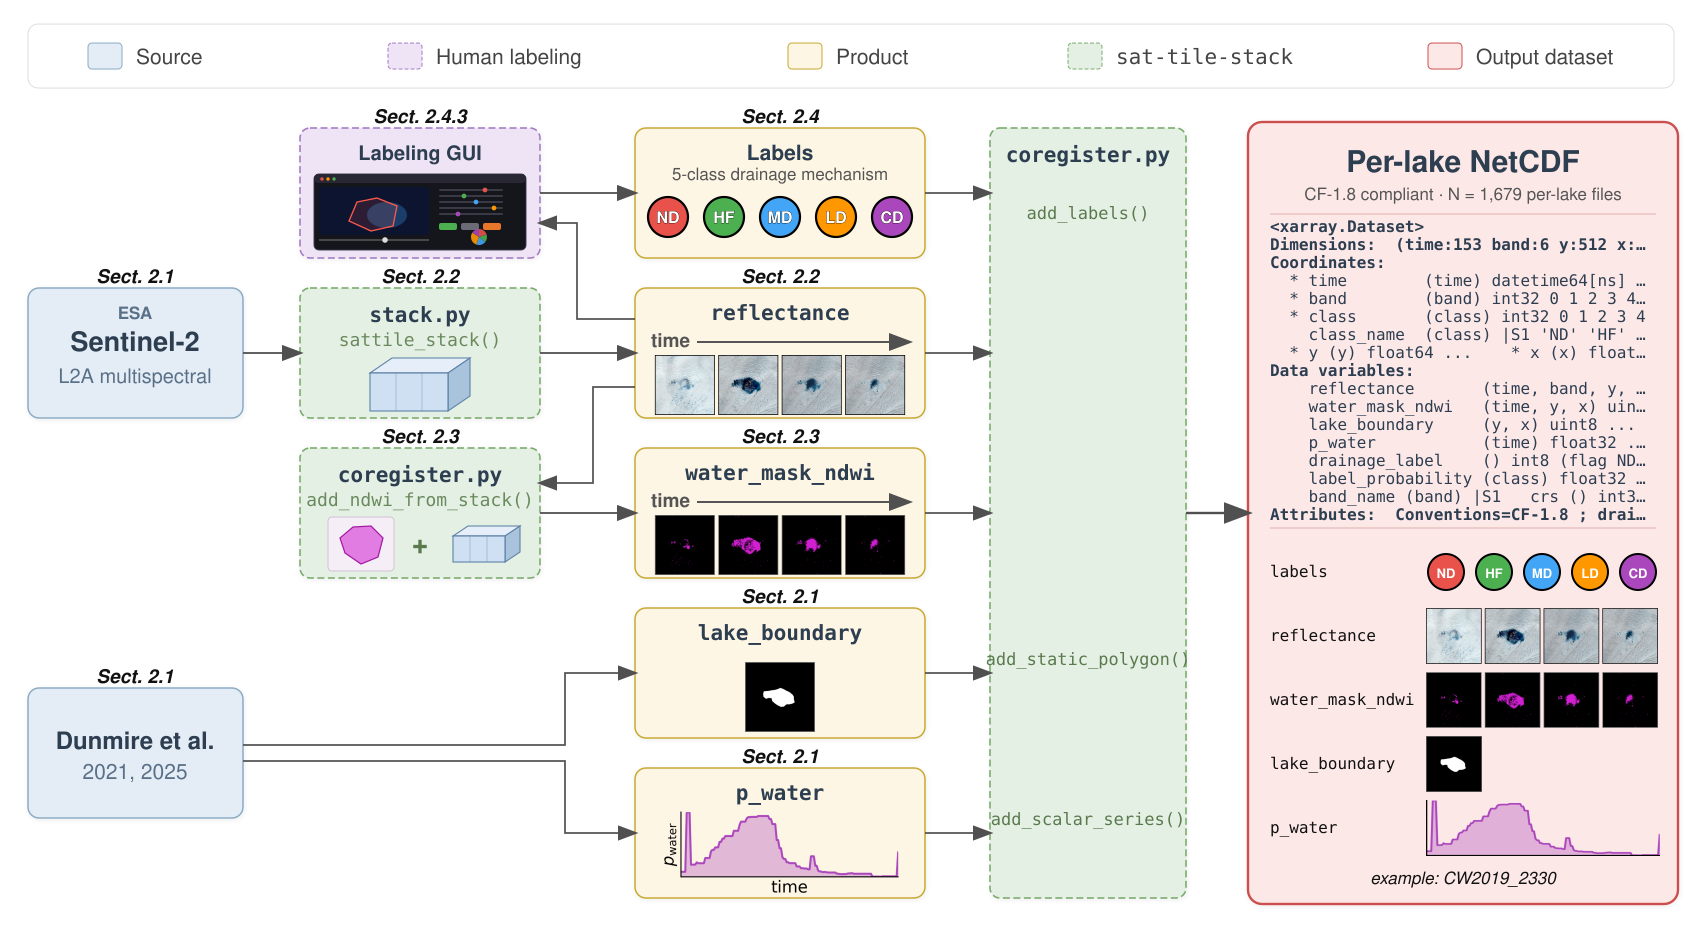

In [3]:
# ========================================================================
# PIPELINE FIGURE -- with-methods variant for the GitHub README
# (same layout as ESSD Figure 2; method names retained for API context)
# ========================================================================
from IPython.display import SVG, display

TILES_B64 = globals().get('TILES_B64', '')
CURVE_B64 = globals().get('CURVE_B64', '')
NDWI_TILES_B64 = globals().get('NDWI_TILES_B64', '')
BOUNDARY_B64 = globals().get('BOUNDARY_B64', '')
CURVE_MINI_B64 = globals().get('CURVE_MINI_B64', '')

XS, WS = 28, 215         # A  sources (blue)
XB, WB = 300, 240        # B  GUI / stack.py / coregister.py(ndwi)
XP, WP = 635, 290        # C  products (yellow)
XD, WD = 990, 196        # D  coregister.py spine
XO, WO = 1248, 430       # E  output (red)
BH = 130
PY = [193, 353, 513, 673, 833]
VW = XO + WO + 24
DY = (PY[3] + PY[4]) // 2
CXC = XP + WP // 2
TOP = PY[0] - BH // 2
BOT = PY[4] + BH // 2
VH = BOT + 32
KINK = XP - 70
GRN_F, GRN_S = '#e4f0e4', '#7aab6e'

_lbl = ''
_cls = [('#e8524a','ND'),('#4caf50','HF'),('#42a5f5','MD'),('#ff9800','LD'),('#ab47bc','CD')]
_csp = 56
_cx0 = XP + (WP - _csp*4)//2
for i, (c, n) in enumerate(_cls):
    cx = _cx0 + i * _csp
    _lbl += f'<circle cx="{cx}" cy="{PY[0]+24}" r="20" fill="{c}" stroke="#000000" stroke-width="2.2"/>'
    _lbl += (f'<text x="{cx}" y="{PY[0]+30}" text-anchor="middle" font-size="16" '
             f'font-weight="bold" fill="white" stroke="#000000" stroke-width="0.6" '
             f'paint-order="stroke">{n}</text>')

_tile = ((f'<text x="{XP+16}" y="{PY[1]-6}" text-anchor="start" font-size="19" '
          f'font-weight="bold" fill="#555">time</text>'
          f'<line x1="{XP+62}" y1="{PY[1]-11}" x2="{XP+WP-16}" y2="{PY[1]-11}" '
          f'stroke="#555" stroke-width="2" marker-end="url(#a)"/>'
          f'<image href="data:image/png;base64,{TILES_B64}" x="{XP+14}" y="{PY[1]+2}" '
          f'width="{WP-28}" height="60" preserveAspectRatio="xMidYMid meet"/>') if TILES_B64 else '')
_ndwi_tiles = ((f'<text x="{XP+16}" y="{PY[2]-6}" text-anchor="start" font-size="19" '
                f'font-weight="bold" fill="#555">time</text>'
                f'<line x1="{XP+62}" y1="{PY[2]-11}" x2="{XP+WP-16}" y2="{PY[2]-11}" '
                f'stroke="#555" stroke-width="2" marker-end="url(#a)"/>'
                f'<image href="data:image/png;base64,{NDWI_TILES_B64}" x="{XP+14}" y="{PY[2]+2}" '
                f'width="{WP-28}" height="60" preserveAspectRatio="xMidYMid meet"/>') if NDWI_TILES_B64 else '')
_bnd_side = 70
_boundary = ((f'<image href="data:image/png;base64,{BOUNDARY_B64}" '
              f'x="{XP+(WP-_bnd_side)//2}" y="{PY[3]-_bnd_side//2+24}" '
              f'width="{_bnd_side}" height="{_bnd_side}" preserveAspectRatio="xMidYMid meet"/>') if BOUNDARY_B64 else '')
if CURVE_B64:
    _curve = (f'<image href="data:image/png;base64,{CURVE_B64}" x="{XP+8}" y="{PY[4]-22}" '
              f'width="{WP-16}" height="86" preserveAspectRatio="xMidYMid meet"/>')
else:
    _px, _py = XP + 28, PY[4] + 10
    _curve = (f'<polyline points="{_px},{_py+44} {_px+40},{_py+34} {_px+80},{_py+16} {_px+120},{_py+4} '
              f'{_px+160},{_py+10} {_px+200},{_py+26} {_px+235},{_py+42}" fill="none" '
              f'stroke="#ab47bc" stroke-width="2.4" opacity="0.7"/>')

_NC = [
 "<xarray.Dataset>",
 "Dimensions:  (time:153 band:6 y:512 x:512 class:5)",
 "Coordinates:",
 "  * time        (time) datetime64[ns] 2019-05-01 ...",
 "  * band        (band) int32 0 1 2 3 4 5",
 "  * class       (class) int32 0 1 2 3 4",
 "    class_name  (class) |S1 'ND' 'HF' 'MD' 'LD' 'CD'",
 "  * y (y) float64 ...    * x (x) float64 ...",
 "Data variables:",
 "    reflectance       (time, band, y, x) float32 ...",
 "    water_mask_ndwi   (time, y, x) uint8 ...",
 "    lake_boundary     (y, x) uint8 ...",
 "    p_water           (time) float32 ...",
 "    drainage_label    () int8 (flag ND HF MD LD CD)",
 "    label_probability (class) float32 ...",
 "    band_name (band) |S1   crs () int32   +9 prov.",
 "Attributes:  Conventions=CF-1.8 ; drainage_label ; history",
]
_hdr = ("<xarray.Dataset>", "Dimensions:", "Coordinates:",
        "Data variables:", "Attributes:")
def _esc(s):
    return s.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")
_MAXC = max(18, int((WO - 46) / 9.8))
_rx, _ry, _rdy = XO + 22, TOP + 104, 18
_nc_repr = ""
for _k, _ln in enumerate(_NC):
    _bold = ' font-weight="bold"' if _ln.startswith(_hdr) else ''
    _t = _ln if len(_ln) <= _MAXC else _ln[:_MAXC-1] + "…"
    _nc_repr += (f'<text x="{_rx}" y="{_ry + _k*_rdy}" font-size="16" '
                 f'font-family="monospace"{_bold} fill="#2c3e50" '
                 f'xml:space="preserve">{_esc(_t)}</text>')

_P0, _PRH, _GH = TOP + 412, 64, 56
_STRIPW = int(round(_GH * 1026 / 246))
_capx, _gx = XO + 22, XO + 178
_gw = WO - 198
def _mini(b64, cy):
    return (f'<image href="data:image/png;base64,{b64}" x="{_gx}" y="{cy-_GH//2}" '
            f'width="{_gw}" height="{_GH}" preserveAspectRatio="xMinYMid meet"/>'
            ) if b64 else ''
_prod_rows = [
  ('labels', None),
  ('reflectance', TILES_B64),
  ('water_mask_ndwi', NDWI_TILES_B64),
  ('lake_boundary', BOUNDARY_B64),
  ('p_water', CURVE_MINI_B64),
]
_out_products = ""
for _i, (_cap, _b64) in enumerate(_prod_rows):
    _cy = _P0 + _i * _PRH + _PRH // 2
    _out_products += (f'<text x="{_capx}" y="{_cy+5}" font-size="16" '
                      f'font-family="monospace" fill="#111111">{_cap}</text>')
    if _cap == 'labels':
        for _j, (_c, _n) in enumerate([('#e8524a','ND'),('#4caf50','HF'),
                ('#42a5f5','MD'),('#ff9800','LD'),('#ab47bc','CD')]):
            _lx = _gx + 20 + _j * 48
            _out_products += (f'<circle cx="{_lx}" cy="{_cy}" r="18" fill="{_c}" '
                              f'stroke="#000" stroke-width="2"/>'
                              f'<text x="{_lx}" y="{_cy+6}" text-anchor="middle" '
                              f'font-size="13" font-weight="bold" fill="white">{_n}</text>')
    elif _cap == 'lake_boundary':
        _out_products += ((f'<image href="data:image/png;base64,{_b64}" '
                           f'x="{_gx}" y="{_cy-_GH//2}" width="{_GH}" height="{_GH}" '
                           f'preserveAspectRatio="xMidYMid meet"/>') if _b64 else '')
    elif _cap == 'p_water':
        _out_products += ((f'<image href="data:image/png;base64,{_b64}" '
                           f'x="{_gx}" y="{_cy-_GH//2}" width="{_STRIPW}" height="{_GH}" '
                           f'preserveAspectRatio="none"/>') if _b64 else '')
    else:
        _out_products += _mini(_b64, _cy)

def sect_tag(cx, top, txt):
    return (f'<text x="{cx}" y="{top-5}" text-anchor="middle" font-size="19" '
            f'font-weight="bold" fill="#111111" font-style="italic">{txt}</text>')

def code_box(x, y, w, h, title, sub_lines, sect):
    s = (f'<rect x="{x}" y="{y}" width="{w}" height="{h}" rx="10" fill="{GRN_F}" '
         f'stroke="{GRN_S}" stroke-width="1.6" stroke-dasharray="7,3.5" filter="url(#sh)"/>'
         f'<text x="{x+w//2}" y="{y+34}" text-anchor="middle" font-size="21" '
         f'font-weight="bold" fill="#2c3e50" font-family="monospace">{title}</text>')
    yy = y + 58
    for ln in sub_lines:
        s += (f'<text x="{x+w//2}" y="{yy}" text-anchor="middle" font-size="18" '
              f'fill="#6a8a5e" font-family="monospace">{ln}</text>')
        yy += 19
    return (sect_tag(x + w // 2, y, sect) if sect else '') + s

def prod_box(yc, title, sub, sect, mono=False, sub_size=13):
    y = yc - BH // 2
    ff = ' font-family="monospace"' if mono else ''
    return (sect_tag(CXC, y, sect) + f'<rect x="{XP}" y="{y}" width="{WP}" height="{BH}" rx="11" fill="#fef6e4" '
            f'stroke="#c8a830" stroke-width="1.5" filter="url(#sh)"/>'
            f'<text x="{CXC}" y="{y+32}" text-anchor="middle" font-size="21" '
            f'font-weight="bold" fill="#2c3e50"{ff}>{title}</text>'
            f'<text x="{CXC}" y="{y+52}" text-anchor="middle" font-size="{sub_size}" fill="#555">{sub}</text>')

_sg_y = PY[1] - BH // 2

def data_cube(cx, cy, fw, fh, dx, dy):
    lx = cx - (fw + dx) // 2
    ty = cy - (fh + dy) // 2
    Ax, Ay = lx, ty + dy
    Bx, By = lx + fw, ty + dy
    Cx, Cy = lx + fw, ty + dy + fh
    Dx, Dy = lx, ty + dy + fh
    A2x, A2y = lx + dx, ty
    B2x, B2y = lx + fw + dx, ty
    C2x, C2y = lx + fw + dx, ty + fh
    s1, s2 = lx + fw // 3, lx + 2 * fw // 3
    return (
      f'<path d="M{Ax},{Ay} L{A2x},{A2y} L{B2x},{B2y} L{Bx},{By} Z" fill="#e6eef9" stroke="#5d82a6" stroke-width="1.1"/>'
      f'<path d="M{Bx},{By} L{B2x},{B2y} L{C2x},{C2y} L{Cx},{Cy} Z" fill="#aac3dd" stroke="#5d82a6" stroke-width="1.1"/>'
      f'<path d="M{Ax},{Ay} L{Bx},{By} L{Cx},{Cy} L{Dx},{Dy} Z" fill="#cfe0f2" stroke="#5d82a6" stroke-width="1.1"/>'
      f'<line x1="{s1}" y1="{Ay}" x2="{s1}" y2="{Cy}" stroke="#6f93b5" stroke-width="0.8" opacity="0.55"/>'
      f'<line x1="{s2}" y1="{Ay}" x2="{s2}" y2="{Cy}" stroke="#6f93b5" stroke-width="0.8" opacity="0.55"/>')

_stackpy_glyph = data_cube(XB + WB // 2, _sg_y + 96, 78, 38, 22, 15)

_cgbx  = PY[2] - BH // 2
_cgrow = _cgbx + 96
_mpx, _mpy = XB + 28, _cgrow - 27
_ndwi_glyph = (
  f'<rect x="{_mpx}" y="{_mpy}" width="66" height="54" rx="4" fill="#f5eef6" stroke="#cbb6cf" stroke-width="0.8"/>'
  f'<path d="M{_mpx+17},{_mpy+36} L{_mpx+12},{_mpy+21} L{_mpx+25},{_mpy+10} L{_mpx+43},{_mpy+9} '
  f'L{_mpx+55},{_mpy+21} L{_mpx+50},{_mpy+40} L{_mpx+33},{_mpy+47} Z" '
  f'fill="#d11fd1" fill-opacity="0.55" stroke="#a017a0" stroke-width="1.2"/>'
  f'<text x="{XB + WB // 2}" y="{_cgrow + 9}" text-anchor="middle" font-size="28" '
  f'font-weight="bold" fill="#5a7a4e">+</text>'
  + data_cube(XB + WB - 54, _cgrow, 52, 26, 15, 10))

_cg_y, _cg_h = PY[0] - BH // 2, (PY[4] + BH // 2) - (PY[0] - BH // 2)

# Method names on the right-spine coregister.py block (with-methods variant).
_cg_list = (
  f'<text x="{XD+WD//2}" y="{PY[0]+26}" text-anchor="middle" font-size="17" fill="#5a7a4e" font-family="monospace">add_labels()</text>'
  f'<text x="{XD+WD//2}" y="{PY[3]-8}" text-anchor="middle" font-size="17" fill="#5a7a4e" font-family="monospace">add_static_polygon()</text>'
  f'<text x="{XD+WD//2}" y="{PY[4]-8}" text-anchor="middle" font-size="17" fill="#5a7a4e" font-family="monospace">add_scalar_series()</text>')

import math as _m
gx, gy, gw, gh = XB+14, PY[0]-BH//2+46, WB-28, BH-54
y0 = gy + 11
ix, iy, iw, ih = gx+5, y0+2, 110, 48
rx = ix + iw + 10
rw = gx + gw - rx - 6
_pie_cn = [137,112,130,200,108]
_pie_co = ['#e8524a','#4caf50','#42a5f5','#ff9800','#ab47bc']
_pcx, _pcy, _pr = rx + rw//2, y0+52, 8
_pie = ''
_a = -_m.pi/2
for _c, _co in zip(_pie_cn, _pie_co):
    _a1 = _a + _c/sum(_pie_cn)*2*_m.pi
    _x0,_y0 = _pcx+_pr*_m.cos(_a),  _pcy+_pr*_m.sin(_a)
    _x1,_y1 = _pcx+_pr*_m.cos(_a1), _pcy+_pr*_m.sin(_a1)
    _pie += (f'<path d="M{_pcx},{_pcy} L{_x0:.1f},{_y0:.1f} '
             f'A{_pr},{_pr} 0 0 1 {_x1:.1f},{_y1:.1f} Z" fill="{_co}" opacity="0.9"/>')
    _a = _a1
_sld = ''
_fr = [0.72,0.40,0.58,0.86,0.30]
for _i,(_co,_f) in enumerate(zip(_pie_co,_fr)):
    _ry = y0 + 4 + _i*6
    _sld += (f'<rect x="{rx}" y="{_ry}" width="64" height="2" rx="1" fill="#3a3a46"/>'
             f'<circle cx="{rx+int(_f*64)}" cy="{_ry+1}" r="2.4" fill="{_co}"/>')
_btn = ''
for _k,_bc in enumerate(['#4caf50','#6b6b76','#e8772a']):
    _btn += f'<rect x="{rx+_k*22}" y="{y0+38}" width="18" height="7" rx="2" fill="{_bc}"/>'
_gui_graphic = (
  f'<rect x="{gx}" y="{gy}" width="{gw}" height="{gh}" rx="5" fill="#15161b" stroke="#3a3550" stroke-width="0.9"/>'
  f'<rect x="{gx}" y="{gy}" width="{gw}" height="9" rx="5" fill="#2a2735"/>'
  f'<circle cx="{gx+8}" cy="{gy+5}" r="1.7" fill="#e8524a"/>'
  f'<circle cx="{gx+14}" cy="{gy+5}" r="1.7" fill="#ff9800"/>'
  f'<circle cx="{gx+20}" cy="{gy+5}" r="1.7" fill="#4caf50"/>'
  f'<rect x="{ix}" y="{iy}" width="{iw}" height="{ih}" rx="2" fill="#0c1430"/>'
  f'<ellipse cx="{ix+iw*0.62:.0f}" cy="{iy+ih*0.58:.0f}" rx="20" ry="13" fill="#2a6fb0" opacity="0.45"/>'
  f'<path d="M{ix+30},{iy+34} L{ix+38},{iy+15} L{ix+58},{iy+11} L{ix+78},{iy+19} '
  f'L{ix+74},{iy+39} L{ix+52},{iy+44} Z" fill="#e8524a" fill-opacity="0.15" '
  f'stroke="#ff5a4a" stroke-width="1.3"/>'
  f'<line x1="{ix}" y1="{iy+ih+5}" x2="{ix+iw}" y2="{iy+ih+5}" stroke="#555" stroke-width="1.6"/>'
  f'<circle cx="{ix+int(0.6*iw)}" cy="{iy+ih+5}" r="2.8" fill="#ddd"/>'
  + _sld + _btn + _pie )

svg = f"""<svg xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink"
     viewBox="0 0 {VW} {VH}" font-family="'Helvetica Neue', Helvetica, Arial, sans-serif">
  <defs>
    <marker id="a" markerWidth="12" markerHeight="9" refX="10" refY="4.5" orient="auto">
      <polygon points="0 0,12 4.5,0 9" fill="#505050"/></marker>
    <filter id="sh" x="-2%" y="-4%" width="104%" height="110%">
      <feDropShadow dx="0.8" dy="1.6" stdDeviation="2.4" flood-opacity="0.07"/></filter>
  </defs>
  <rect width="100%" height="100%" fill="white"/>

  {sect_tag(XS+WS//2, PY[1]-BH//2, "Sect. 2.1")}
  <rect x="{XS}" y="{PY[1]-BH//2}" width="{WS}" height="{BH}" rx="11" fill="#e4edf6" stroke="#8aabc4" stroke-width="1.5" filter="url(#sh)"/>
  <text x="{XS+WS//2}" y="{PY[1]-34}" text-anchor="middle" font-size="17" font-weight="bold" fill="#5a7088">ESA</text>
  <text x="{XS+WS//2}" y="{PY[1]-2}" text-anchor="middle" font-size="27" font-weight="bold" fill="#2c3e50">Sentinel-2</text>
  <text x="{XS+WS//2}" y="{PY[1]+30}" text-anchor="middle" font-size="20" fill="#5a7088">L2A multispectral</text>

  {sect_tag(XS+WS//2, DY-BH//2, "Sect. 2.1")}
  <rect x="{XS}" y="{DY-BH//2}" width="{WS}" height="{BH}" rx="11" fill="#e4edf6" stroke="#8aabc4" stroke-width="1.5" filter="url(#sh)"/>
  <text x="{XS+WS//2}" y="{DY-4}" text-anchor="middle" font-size="24" font-weight="bold" fill="#2c3e50">Dunmire et al.</text>
  <text x="{XS+WS//2}" y="{DY+26}" text-anchor="middle" font-size="21" fill="#5a7088">2021, 2025</text>

  {sect_tag(XB+WB//2, PY[0]-BH//2, "Sect. 2.4.3")}
  <rect x="{XB}" y="{PY[0]-BH//2}" width="{WB}" height="{BH}" rx="10" fill="#efe4f5" stroke="#a47cc6" stroke-width="1.6" stroke-dasharray="7,3.5" filter="url(#sh)"/>
  <text x="{XB+WB//2}" y="{PY[0]-BH//2+32}" text-anchor="middle" font-size="20" font-weight="bold" fill="#2c3e50">Labeling GUI</text>
  {_gui_graphic}

  {code_box(XB, PY[1]-BH//2, WB, BH, 'stack.py', ['sattile_stack()'], 'Sect. 2.2')}
  {_stackpy_glyph}

  {code_box(XB, PY[2]-BH//2, WB, BH, 'coregister.py', ['add_ndwi_from_stack()'], 'Sect. 2.3')}
  {_ndwi_glyph}

  {prod_box(PY[0], 'Labels', '5-class drainage mechanism', 'Sect. 2.4', sub_size=17)}
  {_lbl}
  {prod_box(PY[1], 'reflectance', '', 'Sect. 2.2', mono=True)}
  {_tile}
  {prod_box(PY[2], 'water_mask_ndwi', '', 'Sect. 2.3', mono=True)}
  {_ndwi_tiles}
  {prod_box(PY[3], 'lake_boundary', '', 'Sect. 2.1', mono=True)}
  {_boundary}
  {prod_box(PY[4], 'p_water', '', 'Sect. 2.1', mono=True)}
  {_curve}

  {code_box(XD, _cg_y, WD, _cg_h, 'coregister.py', [], '')}
  {_cg_list}

  <rect x="{XO}" y="{TOP-6}" width="{WO}" height="{BOT-TOP+12}" rx="14" fill="#fde8e8" stroke="#cc5050" stroke-width="2.4" filter="url(#sh)"/>
  <text x="{XO+WO//2}" y="{TOP+44}" text-anchor="middle" font-size="30" font-weight="bold" fill="#2c3e50">Per-lake NetCDF</text>
  <text x="{XO+WO//2}" y="{TOP+72}" text-anchor="middle" font-size="17" fill="#555">CF-1.8 compliant &#183; N = 1,679 per-lake files</text>
  <line x1="{XO+22}" y1="{TOP+86}" x2="{XO+WO-22}" y2="{TOP+86}" stroke="#e0b0b0" stroke-width="1"/>
  {_nc_repr}
  <line x1="{XO+22}" y1="{TOP+400}" x2="{XO+WO-22}" y2="{TOP+400}" stroke="#e0b0b0" stroke-width="1"/>
  {_out_products}
  <text x="{XO+WO//2}" y="{BOT-14}" text-anchor="middle" font-size="17" fill="#111111" font-style="italic">example: {globals().get("LAKE_ID","CW2019_2330")}</text>

  <line x1="{XS+WS}" y1="{PY[1]}" x2="{XB}" y2="{PY[1]}" stroke="#505050" stroke-width="1.8" marker-end="url(#a)"/>
  <line x1="{XB+WB}" y1="{PY[1]}" x2="{XP}" y2="{PY[1]}" stroke="#505050" stroke-width="1.8" marker-end="url(#a)"/>
  <path d="M{XP},{PY[1]-34} H{XP-58} V{PY[0]+30} H{XB+WB}" fill="none" stroke="#505050" stroke-width="1.7" marker-end="url(#a)"/>
  <line x1="{XB+WB}" y1="{PY[0]}" x2="{XP}" y2="{PY[0]}" stroke="#505050" stroke-width="1.8" marker-end="url(#a)"/>
  <path d="M{XP},{PY[1]+34} H{XP-42} V{PY[2]-30} H{XB+WB}" fill="none" stroke="#505050" stroke-width="1.7" marker-end="url(#a)"/>
  <line x1="{XB+WB}" y1="{PY[2]}" x2="{XP}" y2="{PY[2]}" stroke="#505050" stroke-width="1.8" marker-end="url(#a)"/>
  <path d="M{XS+WS},{DY-8} H{KINK} V{PY[3]} H{XP}" fill="none" stroke="#505050" stroke-width="1.7" marker-end="url(#a)"/>
  <path d="M{XS+WS},{DY+8} H{KINK} V{PY[4]} H{XP}" fill="none" stroke="#505050" stroke-width="1.7" marker-end="url(#a)"/>
  <line x1="{XP+WP}" y1="{PY[0]}" x2="{XD}" y2="{PY[0]}" stroke="#505050" stroke-width="1.7" marker-end="url(#a)"/>
  <line x1="{XP+WP}" y1="{PY[1]}" x2="{XD}" y2="{PY[1]}" stroke="#505050" stroke-width="1.7" marker-end="url(#a)"/>
  <line x1="{XP+WP}" y1="{PY[2]}" x2="{XD}" y2="{PY[2]}" stroke="#505050" stroke-width="1.7" marker-end="url(#a)"/>
  <line x1="{XP+WP}" y1="{PY[3]}" x2="{XD}" y2="{PY[3]}" stroke="#505050" stroke-width="1.7" marker-end="url(#a)"/>
  <line x1="{XP+WP}" y1="{PY[4]}" x2="{XD}" y2="{PY[4]}" stroke="#505050" stroke-width="1.7" marker-end="url(#a)"/>
  <line x1="{XD+WD}" y1="{(PY[0]+PY[4])//2}" x2="{XO}" y2="{(PY[0]+PY[4])//2}" stroke="#505050" stroke-width="2.4" marker-end="url(#a)"/>

  <rect x="{XS}" y="24" width="{VW-2*XS}" height="64" rx="10" fill="white" stroke="#ddd" stroke-width="1"/>
  <rect x="{XS+60}" y="43" width="34" height="26" rx="4" fill="#e4edf6" stroke="#8aabc4" stroke-width="1"/>
  <text x="{XS+108}" y="64" font-size="21" fill="#444">Source</text>
  <rect x="{XS+360}" y="43" width="34" height="26" rx="4" fill="#efe4f5" stroke="#a47cc6" stroke-width="1" stroke-dasharray="4,2"/>
  <text x="{XS+408}" y="64" font-size="21" fill="#444">Human labeling</text>
  <rect x="{XS+760}" y="43" width="34" height="26" rx="4" fill="#fef6e4" stroke="#c8a830" stroke-width="1"/>
  <text x="{XS+808}" y="64" font-size="21" fill="#444">Product</text>
  <rect x="{XS+1040}" y="43" width="34" height="26" rx="4" fill="{GRN_F}" stroke="{GRN_S}" stroke-width="1" stroke-dasharray="4,2"/>
  <text x="{XS+1088}" y="64" font-size="21" fill="#444" font-family="monospace">sat-tile-stack</text>
  <rect x="{XS+1400}" y="43" width="34" height="26" rx="4" fill="#fde8e8" stroke="#cc5050" stroke-width="1"/>
  <text x="{XS+1448}" y="64" font-size="21" fill="#444">Output dataset</text>
</svg>"""

OUT_PNG = OUT_DIR / 'fig2_datapipeline.png'

def _render_png(svg_bytes, out_path):
    # Try in order: cairosvg, then svglib + reportlab. Each is independent;
    # the second has no native deps beyond what reportlab brings.
    try:
        import cairosvg
        cairosvg.svg2png(bytestring=svg_bytes, write_to=str(out_path), scale=3)
        return 'cairosvg'
    except (ImportError, OSError) as e:
        last = f'cairosvg unavailable ({type(e).__name__})'
    try:
        from io import BytesIO
        from svglib.svglib import svg2rlg
        from reportlab.graphics import renderPM
        drawing = svg2rlg(BytesIO(svg_bytes))
        renderPM.drawToFile(drawing, str(out_path), fmt='PNG', dpi=300)
        return 'svglib+reportlab'
    except ImportError:
        return (f'{last}; svglib/reportlab also unavailable. '
                f"Install one: 'pip install cairosvg' "
                f"(needs Cairo system lib) or 'pip install svglib reportlab'.")

method = _render_png(svg.encode(), OUT_PNG)
if Path(OUT_PNG).exists():
    print(f'Saved {OUT_PNG}  ({method})')
else:
    print(method)
display(SVG(data=svg))
